Age and Gender Prediction using ResNet50 Transfer Learning
This notebook builds an end-to-end Age + Gender Prediction model using the UTKFace dataset and ResNet50 as a transfer learning backbone.

The model has two outputs:

Age prediction: regression output
Gender prediction: binary classification output
This notebook is written from scratch and uses a modern tf.data pipeline to avoid old Keras generator errors such as:

TypeError: output_signature must contain objects that are subclass of tf.TypeSpec

Cell 1: Import Required Libraries
This cell imports all important libraries used for dataset handling, image preprocessing, model building, training, evaluation, and prediction


In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Cell 2: Kaggle Secret Key Method
Use this cell in Google Colab.

Before running it, add these two secrets in Colab:

KAGGLE_USERNAME
KAGGLE_KEY
Go to: Left sidebar → Secrets icon → Add new secret.

In [2]:

from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded from Colab secrets.")




Kaggle credentials loaded from Colab secrets.


Cell 4: Download UTKFace dataset
This cell downloads the UTKFace dataset from Kaggle. UTKFace image filenames contain labels in this format:

age_gender_race_date.jpg

Example: 25_0_0_201701.jpg means age 25 and gender 0.

In [3]:
!kaggle datasets download -d jangedoo/utkface-new -p /content --force


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:03<00:00, 109MB/s]



Cell 5: Extract dataset
The downloaded file is a ZIP file. This cell extracts it into the /content directory.

In [4]:
zip_path = "/content/utkface-new.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


Cell 6: Define dataset path
After extraction, UTKFace images are usually stored in this folder.

In [5]:
folder_path = Path("/content/utkface_aligned_cropped/UTKFace")

print("Folder exists:", folder_path.exists())
print("Total files:", len(list(folder_path.glob("*.jpg"))))

Folder exists: True
Total files: 23708


Cell 7: Create dataframe from image filenames
This cell reads filenames and extracts age and gender labels.

Gender labels in UTKFace:

0 = Male
1 = Female

In [6]:
records = []

for img_file in folder_path.glob("*.jpg"):
    try:
        parts = img_file.name.split("_")
        age = int(parts[0])
        gender = int(parts[1])

        if gender in [0, 1] and 1 <= age <= 116:
            records.append({
                "image_path": str(img_file),
                "age": age,
                "gender": gender
            })
    except Exception:
        continue

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (23708, 3)


,image_path,age,gender
0,/content/utkface_aligned_cropped/UTKFace/27_1_...,27,1
1,/content/utkface_aligned_cropped/UTKFace/28_1_...,28,1
2,/content/utkface_aligned_cropped/UTKFace/26_0_...,26,0
3,/content/utkface_aligned_cropped/UTKFace/21_0_...,21,0
4,/content/utkface_aligned_cropped/UTKFace/51_0_...,51,0


Cell 7: Check Age and Gender Distribution
This helps us understand whether the dataset is balanced or imbalanced.

Gender distribution:
gender
0    12391
1    11317
Name: count, dtype: int64


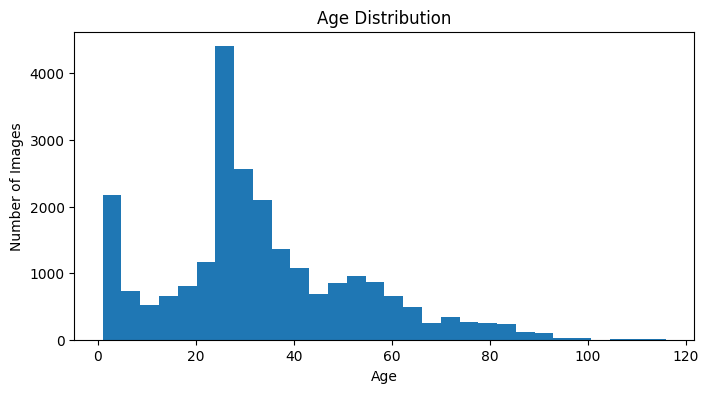

In [7]:
print("Gender distribution:")
print(df["gender"].value_counts())

plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")
plt.show()



Cell 8: Split Data into Training and Validation Sets
We use 80% data for training and 20% for validation.

In [8]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["gender"]
)

print("Training samples:", train_df.shape)
print("Validation samples:", val_df.shape)


Training samples: (18966, 3)
Validation samples: (4742, 3)


Cell 9: Create TensorFlow Dataset Pipeline
This modern tf.data pipeline avoids the old ImageDataGenerator multi-output problem.

For each image, it returns:

image, {"age": age_label, "gender": gender_label}
This structure exactly matches our model outputs.

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image_and_labels(image_path, age, gender):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    labels = {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32)
    }

    return image, labels


def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, ages, genders))
    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df,shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

print("TensorFlow datasets created successfully.")


TensorFlow datasets created successfully.


Cell 10: Visualize Sample Images
This cell displays a few sample images with their age and gender labels.

Remember:

0 = Male
1 = Female

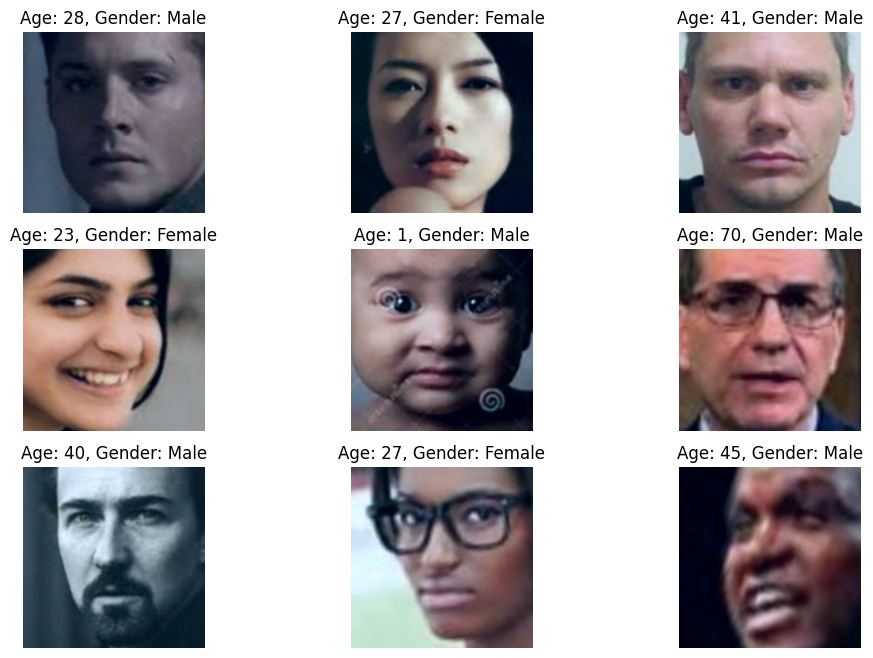

In [10]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(9):
        img = images[i].numpy()
        # Reverse ResNet preprocessing approximately for display
        img = img[..., ::-1]
        img = img + np.array([103.939, 116.779, 123.68])
        img = np.clip(img, 0, 255).astype("uint8")

        age = int(labels["age"][i].numpy())
        gender = int(labels["gender"][i].numpy())
        gender_name = "Female" if gender == 1 else "Male"

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Age: {age}, Gender: {gender_name}")
        plt.axis("off")
    plt.show()

Cell 11: Build ResNet50 Transfer Learning Model
We use ResNet50 pretrained on ImageNet.

Important points:

include_top=False removes the original ImageNet classifier.
base_model.trainable=False freezes ResNet50 layers.
We add our own custom heads for age and gender.

In [11]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

age_output = layers.Dense(1, activation="linear", name="age")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

model = Model(inputs=inputs, outputs={"age": age_output, "gender": gender_output})

model.summary()




94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,768,642 (94.48 MB)

 Trainable params: 1,180,930 (4.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Cell 12: Compile the Model
The model uses two losses:

Age loss: Mean Absolute Error because age is a regression problem.
Gender loss: Binary Crossentropy because gender is binary classification.
We also use loss weights so that gender learning is not ignored.

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0
    }
)

Cell 13: Define Callbacks
Callbacks help improve training:

EarlyStopping stops training if validation loss stops improving.
ModelCheckpoint saves the best model.
ReduceLROnPlateau reduces learning rate when training becomes stuck.

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet50_age_gender_model.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

Cell 14: Train the Model
This trains only the custom top layers while ResNet50 remains frozen.

Start with 10 epochs. You can increase it later.

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 102s 140ms/step - age_loss: 11.5704 - age_mae: 11.5719 - gender_accuracy: 0.7900 - gender_loss: 0.4858 - loss: 14.0005 - val_age_loss: 8.8338 - val_age_mae: 8.8356 - val_gender_accuracy: 0.8520 - val_gender_loss: 0.3283 - val_loss: 10.4814 - learning_rate: 1.0000e-04
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 119s 117ms/step - age_loss: 8.6159 - age_mae: 8.6161 - gender_accuracy: 0.8439 - gender_loss: 0.3684 - loss: 10.4583 - val_age_loss: 7.8314 - val_age_mae: 7.8301 - val_gender_accuracy: 0.8686 - val_gender_loss: 0.2962 - val_loss: 9.3153 - learning_rate: 1.0000e-04
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - age_loss: 8.0434 - age_mae: 8.0431 - gender_accuracy: 0.8594 - gender_loss: 0.3255 - loss: 9.6713 - val_age_loss: 7.5600 - val_age_mae: 7.5644 - val_gender_accuracy: 0.8726 - val_gender_loss: 0.2853 - val_loss: 8.9945 - learning_rate: 1.0000e-04
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 83s 136ms/step - age_loss: 7.7096 - age_mae:

Cell 15: Plot Training Curves
This cell plots age error and gender accuracy.



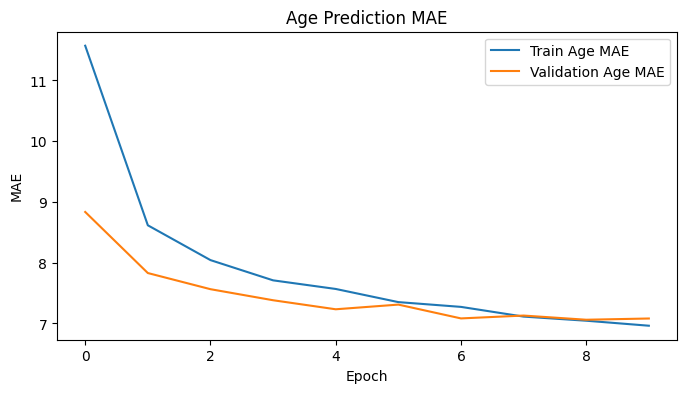

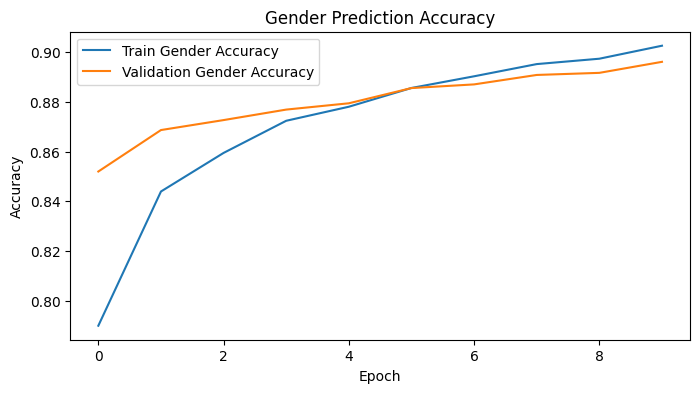

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["age_mae"], label="Train Age MAE")
plt.plot(history.history["val_age_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["gender_accuracy"], label="Train Gender Accuracy")
plt.plot(history.history["val_gender_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Cell 16: Fine-Tuning ResNet50
After training the custom head, we unfreeze the last few ResNet50 layers and train with a very small learning rate.

Fine-tuning can improve performance.

In [16]:
base_model.trainable = True

# Freeze earlier layers and fine-tune only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0
    }
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 133s 184ms/step - age_loss: 7.9956 - age_mae: 7.9951 - gender_accuracy: 0.8721 - gender_loss: 0.3021 - loss: 9.5055 - val_age_loss: 7.0358 - val_age_mae: 7.0391 - val_gender_accuracy: 0.8929 - val_gender_loss: 0.2652 - val_loss: 8.3700 - learning_rate: 1.0000e-05
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 105s 173ms/step - age_loss: 6.6399 - age_mae: 6.6396 - gender_accuracy: 0.9047 - gender_loss: 0.2302 - loss: 7.7908 - val_age_loss: 6.7735 - val_age_mae: 6.7758 - val_gender_accuracy: 0.8981 - val_gender_loss: 0.2522 - val_loss: 8.0416 - learning_rate: 1.0000e-05
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 99s 163ms/step - age_loss: 5.7990 - age_mae: 5.7994 - gender_accuracy: 0.9226 - gender_loss: 0.1905 - loss: 6.7514 - val_age_loss: 6.4874 - val_age_mae: 6.4968 - val_gender_accuracy: 0.9022 - val_gender_loss: 0.2469 - val_loss: 7.7355 - learning_rate: 1.0000e-05
Epoch 4/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 98s 163ms/step - age_loss: 5.3038 - age_mae: 5.3040 -

Cell 17: Evaluate the Model
This cell evaluates the final model on validation data.

In [17]:
results = model.evaluate(val_ds)
print("Evaluation Results:", results)


149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - age_loss: 6.4147 - age_mae: 6.4188 - gender_accuracy: 0.9072 - gender_loss: 0.2490 - loss: 7.6693
Evaluation Results: [7.669340133666992, 6.414707183837891, 0.24903547763824463, 6.41884708404541, 0.9072121381759644]


Cell 18: Predict Age and Gender on One Image
Upload or give the path of any face image and run this function.

In [18]:
from google.colab import files
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
def predict_age_gender():
    # 1. Upload widget
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # 2. Load image
    img = load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Predict
    prediction = model.predict(img_array)

    print("DEBUG:", type(prediction))
    print("DEBUG:", prediction)

    # 4. Handle all possible output formats
    if isinstance(prediction, dict):
        age = prediction["age"][0][0]
        gender_prob = prediction["gender"][0][0]

    elif isinstance(prediction, list):
        age = prediction[0][0][0]
        gender_prob = prediction[1][0][0]

    else:
        # Single array output (most common)
        age = prediction[0][0]
        gender_prob = prediction[0][1]

    gender = "Female" if gender_prob >= 0.5 else "Male"

    # 5. Show image + results
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted Age: {age:.1f}, Gender: {gender}")
    plt.show()

    print(f"Predicted Age: {age:.1f}")
    print(f"Predicted Gender: {gender}")
    print(f"Gender Probability Female: {gender_prob:.3f}")
predict_age_gender()



Cell 19: Save Final Model
This saves the final trained model.



In [20]:
model.save("resnet50_age_gender_final_model.keras")
print("Model saved successfully.")

Model saved successfully.


Cell 20: Load Saved Model
Use this cell when you want to reuse the trained model later.

In [21]:
loaded_model = tf.keras.models.load_model("resnet50_age_gender_final_model.keras")
print("Model loaded successfully.")

Model loaded successfully.


In [24]:
from google.colab import files
files.download("best_resnet50_age_gender_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

In [29]:
test = model.predict(np.zeros((1, 224, 224, 3)))
print(test)
print(type(test))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
{'age': array([[34.584587]], dtype=float32), 'gender': array([[0.83222556]], dtype=float32)}
<class 'dict'>


In [30]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image

# Load model
model = load_model("best_resnet50_age_gender_model.keras")
IMG_SIZE = 224

def predict(image):
    try:
        # Ensure RGB
        img = image.convert("RGB")

        # Resize
        img = img.resize((IMG_SIZE, IMG_SIZE))

        # Preprocess
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array)

        # Extract from DICTIONARY
        age = float(prediction["age"][0][0])
        gender_prob = float(prediction["gender"][0][0])

        gender = "Female" if gender_prob >= 0.5 else "Male"

        return (
            f"Predicted Age: {age:.1f}\n"
            f"Predicted Gender: {gender}\n"
            f"Female Probability: {gender_prob:.3f}"
        )

    except Exception as e:
        return f"Error: {str(e)}"

interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Textbox(label="Prediction"),
    title="Age & Gender Prediction",
    description="Upload a face image to predict age and gender."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f220a9b7b5b74b3427.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
